In [145]:
import sys
print(sys.executable)

import pandas as pd
import numpy as np

print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)

c:\Users\HP\anaconda3\envs\mlprojects\python.exe
Pandas: 3.0.5
NumPy: 2.4.6


In [146]:
import pandas as pd

calendar = pd.read_csv("../calendar.csv")
sales = pd.read_csv("../sales_train_validation.csv")
prices = pd.read_csv("../sell_prices.csv")

print("Calendar shape:", calendar.shape)
print("Sales shape:", sales.shape)
print("Prices shape:", prices.shape)

Calendar shape: (1969, 14)
Sales shape: (30490, 1919)
Prices shape: (6841121, 4)


In [147]:
# Check columns
print("Calendar columns:")
print(calendar.columns.tolist())

print("\nSales columns:")
print(sales.columns.tolist()[:15], "...")

print("\nPrices columns:")
print(prices.columns.tolist())

# View first 5 rows
print("\nCalendar:")
print(calendar.head())

print("\nSales:")
print(sales.head())

print("\nPrices:")
print(prices.head())

Calendar columns:
['date', 'wm_yr_wk', 'weekday', 'wday', 'month', 'year', 'd', 'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2', 'snap_CA', 'snap_TX', 'snap_WI']

Sales columns:
['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'd_1', 'd_2', 'd_3', 'd_4', 'd_5', 'd_6', 'd_7', 'd_8', 'd_9'] ...

Prices columns:
['store_id', 'item_id', 'wm_yr_wk', 'sell_price']

Calendar:
         date  wm_yr_wk    weekday  wday  month  year    d event_name_1  \
0  2011-01-29     11101   Saturday     1      1  2011  d_1          NaN   
1  2011-01-30     11101     Sunday     2      1  2011  d_2          NaN   
2  2011-01-31     11101     Monday     3      1  2011  d_3          NaN   
3  2011-02-01     11101    Tuesday     4      2  2011  d_4          NaN   
4  2011-02-02     11101  Wednesday     5      2  2011  d_5          NaN   

  event_type_1 event_name_2 event_type_2  snap_CA  snap_TX  snap_WI  
0          NaN          NaN          NaN        0        0        0  
1       

In [148]:
print("Calendar missing values:")
print(calendar.isnull().sum())

print("\nSales missing values:")
print(sales.isnull().sum().sort_values(ascending=False).head(20))

print("\nPrices missing values:")
print(prices.isnull().sum())

Calendar missing values:
date               0
wm_yr_wk           0
weekday            0
wday               0
month              0
year               0
d                  0
event_name_1    1807
event_type_1    1807
event_name_2    1964
event_type_2    1964
snap_CA            0
snap_TX            0
snap_WI            0
dtype: int64

Sales missing values:
id          0
item_id     0
dept_id     0
cat_id      0
store_id    0
state_id    0
d_1         0
d_2         0
d_3         0
d_4         0
d_5         0
d_6         0
d_7         0
d_8         0
d_9         0
d_10        0
d_11        0
d_12        0
d_13        0
d_14        0
dtype: int64

Prices missing values:
store_id      0
item_id       0
wm_yr_wk      0
sell_price    0
dtype: int64


In [149]:
print("\n===== DATA TYPES =====")

print("\nCalendar:")
calendar.info()

print("\nSales:")
sales.info()

print("\nPrices:")
prices.info()


===== DATA TYPES =====

Calendar:
<class 'pandas.DataFrame'>
RangeIndex: 1969 entries, 0 to 1968
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   date          1969 non-null   str  
 1   wm_yr_wk      1969 non-null   int64
 2   weekday       1969 non-null   str  
 3   wday          1969 non-null   int64
 4   month         1969 non-null   int64
 5   year          1969 non-null   int64
 6   d             1969 non-null   str  
 7   event_name_1  162 non-null    str  
 8   event_type_1  162 non-null    str  
 9   event_name_2  5 non-null      str  
 10  event_type_2  5 non-null      str  
 11  snap_CA       1969 non-null   int64
 12  snap_TX       1969 non-null   int64
 13  snap_WI       1969 non-null   int64
dtypes: int64(7), str(7)
memory usage: 215.5 KB

Sales:
<class 'pandas.DataFrame'>
RangeIndex: 30490 entries, 0 to 30489
Columns: 1919 entries, id to d_1913
dtypes: int64(1913), str(6)
memory usage: 446.4 MB

Pric

In [150]:
# Convert date column from string to datetime
calendar["date"] = pd.to_datetime(calendar["date"])

print(calendar["date"].dtype)
print(calendar["date"].head())

datetime64[us]
0   2011-01-29
1   2011-01-30
2   2011-01-31
3   2011-02-01
4   2011-02-02
Name: date, dtype: datetime64[us]


In [151]:
event_columns = [
    "event_name_1",
    "event_type_1",
    "event_name_2",
    "event_type_2"
]

calendar[event_columns] = calendar[event_columns].fillna("None")

In [152]:
print("Missing values after handling:")

print("\nCalendar:")
print(calendar.isnull().sum())

print("\nSales:")
print(sales.isnull().sum().sort_values(ascending=False).head(20))

print("\nPrices:")
print(prices.isnull().sum())


Missing values after handling:

Calendar:
date            0
wm_yr_wk        0
weekday         0
wday            0
month           0
year            0
d               0
event_name_1    0
event_type_1    0
event_name_2    0
event_type_2    0
snap_CA         0
snap_TX         0
snap_WI         0
dtype: int64

Sales:
id          0
item_id     0
dept_id     0
cat_id      0
store_id    0
state_id    0
d_1         0
d_2         0
d_3         0
d_4         0
d_5         0
d_6         0
d_7         0
d_8         0
d_9         0
d_10        0
d_11        0
d_12        0
d_13        0
d_14        0
dtype: int64

Prices:
store_id      0
item_id       0
wm_yr_wk      0
sell_price    0
dtype: int64


In [153]:
# Identify daily sales columns
sales_id_cols = [
    "id",
    "item_id",
    "dept_id",
    "cat_id",
    "store_id",
    "state_id"
]

sales_date_cols = [
    col for col in sales.columns
    if col.startswith("d_")
]

print("Number of daily columns:", len(sales_date_cols))
print("First 10 daily columns:", sales_date_cols[:10])

Number of daily columns: 1913
First 10 daily columns: ['d_1', 'd_2', 'd_3', 'd_4', 'd_5', 'd_6', 'd_7', 'd_8', 'd_9', 'd_10']


In [155]:
# Select useful calendar columns
calendar_small = calendar[
    [
        "d",
        "date",
        "wm_yr_wk",
        "weekday",
        "wday",
        "month",
        "year",
        "event_name_1",
        "event_type_1",
        "snap_CA",
        "snap_TX",
        "snap_WI"
    ]
]

# Merge sales with calendar
sales_calendar = sales_long.merge(
    calendar_small,
    on="d",
    how="left"
)

print("Merged shape:", sales_calendar.shape)
print("\nFirst 5 rows:")
print(sales_calendar.head())

MemoryError: Unable to allocate 445. MiB for an array with shape (58327370,) and data type int64

In [156]:
sales_calendar_prices = sales_calendar.merge(
    prices,
    on=["store_id", "item_id", "wm_yr_wk"],
    how="left"
)

print("Final merged shape:", sales_calendar_prices.shape)

print("\nFirst 5 rows:")
print(
    sales_calendar_prices[
        ["item_id", "store_id", "d", "date", "sales", "sell_price"]
    ].head()
)

Final merged shape: (58327370, 20)

First 5 rows:
         item_id store_id    d       date  sales  sell_price
0  HOBBIES_1_001     CA_1  d_1 2011-01-29      0         NaN
1  HOBBIES_1_002     CA_1  d_1 2011-01-29      0         NaN
2  HOBBIES_1_003     CA_1  d_1 2011-01-29      0         NaN
3  HOBBIES_1_004     CA_1  d_1 2011-01-29      0         NaN
4  HOBBIES_1_005     CA_1  d_1 2011-01-29      0         NaN


In [157]:
print("\nMissing sell_price values:")
print(sales_calendar_prices["sell_price"].isnull().sum())


Missing sell_price values:
12299413


In [159]:
print("Total rows:", len(sales_calendar_prices))

print("\nMissing sell_price:")
print(sales_calendar_prices["sell_price"].isnull().sum())

print("\nMissing percentage:")
print(
    sales_calendar_prices["sell_price"].isnull().mean() * 100
)

Total rows: 58327370

Missing sell_price:
12299413

Missing percentage:
21.08686367994991


In [160]:
# Missing price rows
missing_price = sales_calendar_prices[
    sales_calendar_prices["sell_price"].isnull()
]

print("Missing price rows:", len(missing_price))

print("\nMissing prices by store:")
print(missing_price["store_id"].value_counts())

print("\nMissing prices by state:")
print(missing_price["state_id"].value_counts())

Missing price rows: 12299413

Missing prices by store:
store_id
CA_2    1556961
WI_1    1357342
WI_2    1271529
CA_4    1265551
TX_3    1180942
CA_3    1160796
WI_3    1146068
CA_1    1129842
TX_1    1120154
TX_2    1110228
Name: count, dtype: int64

Missing prices by state:
state_id
CA    5113150
WI    3774939
TX    3411324
Name: count, dtype: int64


In [161]:
print("\nSales when price is missing:")

print(
    missing_price["sales"].value_counts().head(10)
)


Sales when price is missing:
sales
0    12299413
Name: count, dtype: int64


In [162]:
# Create date-based features

sales_calendar_prices["day"] = sales_calendar_prices["date"].dt.day
sales_calendar_prices["week"] = sales_calendar_prices["date"].dt.isocalendar().week.astype(int)
sales_calendar_prices["quarter"] = sales_calendar_prices["date"].dt.quarter

print(
    sales_calendar_prices[
        ["date", "day", "week", "month", "quarter", "year"]
    ].head()
)

        date  day  week  month  quarter  year
0 2011-01-29   29     4      1        1  2011
1 2011-01-29   29     4      1        1  2011
2 2011-01-29   29     4      1        1  2011
3 2011-01-29   29     4      1        1  2011
4 2011-01-29   29     4      1        1  2011


In [163]:
# Sort data by product, store and date
sales_calendar_prices = sales_calendar_prices.sort_values(
    ["item_id", "store_id", "date"]
).reset_index(drop=True)

print(
    sales_calendar_prices[
        ["item_id", "store_id", "date", "sales"]
    ].head(10)
)

       item_id store_id       date  sales
0  FOODS_1_001     CA_1 2011-01-29      3
1  FOODS_1_001     CA_1 2011-01-30      0
2  FOODS_1_001     CA_1 2011-01-31      0
3  FOODS_1_001     CA_1 2011-02-01      1
4  FOODS_1_001     CA_1 2011-02-02      4
5  FOODS_1_001     CA_1 2011-02-03      2
6  FOODS_1_001     CA_1 2011-02-04      0
7  FOODS_1_001     CA_1 2011-02-05      2
8  FOODS_1_001     CA_1 2011-02-06      0
9  FOODS_1_001     CA_1 2011-02-07      0


In [164]:
# Create lag features
group = sales_calendar_prices.groupby(["item_id", "store_id"])["sales"]

sales_calendar_prices["lag_1"] = group.shift(1)
sales_calendar_prices["lag_7"] = group.shift(7)

print(
    sales_calendar_prices[
        ["item_id", "store_id", "date", "sales", "lag_1", "lag_7"]
    ].head(15)
)

        item_id store_id       date  sales  lag_1  lag_7
0   FOODS_1_001     CA_1 2011-01-29      3    NaN    NaN
1   FOODS_1_001     CA_1 2011-01-30      0    3.0    NaN
2   FOODS_1_001     CA_1 2011-01-31      0    0.0    NaN
3   FOODS_1_001     CA_1 2011-02-01      1    0.0    NaN
4   FOODS_1_001     CA_1 2011-02-02      4    1.0    NaN
5   FOODS_1_001     CA_1 2011-02-03      2    4.0    NaN
6   FOODS_1_001     CA_1 2011-02-04      0    2.0    NaN
7   FOODS_1_001     CA_1 2011-02-05      2    0.0    3.0
8   FOODS_1_001     CA_1 2011-02-06      0    2.0    0.0
9   FOODS_1_001     CA_1 2011-02-07      0    0.0    0.0
10  FOODS_1_001     CA_1 2011-02-08      0    0.0    1.0
11  FOODS_1_001     CA_1 2011-02-09      0    0.0    4.0
12  FOODS_1_001     CA_1 2011-02-10      3    0.0    2.0
13  FOODS_1_001     CA_1 2011-02-11      1    3.0    0.0
14  FOODS_1_001     CA_1 2011-02-12      3    1.0    2.0


In [165]:
# Create rolling mean features using only previous days' sales

sales_calendar_prices["rolling_mean_7"] = (
    sales_calendar_prices
    .groupby(["item_id", "store_id"])["sales"]
    .transform(lambda x: x.shift(1).rolling(7).mean())
)

sales_calendar_prices["rolling_mean_28"] = (
    sales_calendar_prices
    .groupby(["item_id", "store_id"])["sales"]
    .transform(lambda x: x.shift(1).rolling(28).mean())
)

print(
    sales_calendar_prices[
        [
            "item_id",
            "store_id",
            "date",
            "sales",
            "lag_1",
            "lag_7",
            "rolling_mean_7",
            "rolling_mean_28"
        ]
    ].head(35)
)

        item_id store_id       date  sales  lag_1  lag_7  rolling_mean_7  \
0   FOODS_1_001     CA_1 2011-01-29      3    NaN    NaN             NaN   
1   FOODS_1_001     CA_1 2011-01-30      0    3.0    NaN             NaN   
2   FOODS_1_001     CA_1 2011-01-31      0    0.0    NaN             NaN   
3   FOODS_1_001     CA_1 2011-02-01      1    0.0    NaN             NaN   
4   FOODS_1_001     CA_1 2011-02-02      4    1.0    NaN             NaN   
5   FOODS_1_001     CA_1 2011-02-03      2    4.0    NaN             NaN   
6   FOODS_1_001     CA_1 2011-02-04      0    2.0    NaN             NaN   
7   FOODS_1_001     CA_1 2011-02-05      2    0.0    3.0        1.428571   
8   FOODS_1_001     CA_1 2011-02-06      0    2.0    0.0        1.285714   
9   FOODS_1_001     CA_1 2011-02-07      0    0.0    0.0        1.285714   
10  FOODS_1_001     CA_1 2011-02-08      0    0.0    1.0        1.285714   
11  FOODS_1_001     CA_1 2011-02-09      0    0.0    4.0        1.142857   
12  FOODS_1_

In [166]:
# Check missing values in newly created features

print("Missing values before handling:")

print(
    sales_calendar_prices[
        ["lag_1", "lag_7", "rolling_mean_7", "rolling_mean_28"]
    ].isnull().sum()
)

Missing values before handling:
lag_1               30490
lag_7              213430
rolling_mean_7     213430
rolling_mean_28    853720
dtype: int64


In [167]:
print("Minimum date:", sales_calendar_prices["date"].min())
print("Maximum date:", sales_calendar_prices["date"].max())

Minimum date: 2011-01-29 00:00:00
Maximum date: 2016-04-24 00:00:00


In [168]:
del sales_calendar_prices

In [169]:
import gc
gc.collect()

0

In [170]:
print("Sales shape:", sales.shape)
print("Calendar shape:", calendar.shape)
print("Prices shape:", prices.shape)

Sales shape: (30490, 1919)
Calendar shape: (1969, 14)
Prices shape: (6841121, 4)


In [171]:
# Get available daily sales columns from sales dataset
sales_date_cols = [
    col for col in sales.columns
    if col.startswith("d_")
]

# Select last 180 available sales days
last_180_days = sales_date_cols[-180:]

print("Number of selected days:", len(last_180_days))
print("First selected day:", last_180_days[0])
print("Last selected day:", last_180_days[-1])

Number of selected days: 180
First selected day: d_1734
Last selected day: d_1913


In [172]:
sales_small = sales[
    sales_id_cols + last_180_days
].copy()

print("Original sales shape:", sales.shape)
print("Reduced sales shape:", sales_small.shape)

Original sales shape: (30490, 1919)
Reduced sales shape: (30490, 186)


In [173]:
sales_small_long = sales_small.melt(
    id_vars=sales_id_cols,
    value_vars=last_180_days,
    var_name="d",
    value_name="sales"
)

print("Sales small shape:", sales_small.shape)
print("Long format shape:", sales_small_long.shape)

print("\nFirst 5 rows:")
print(sales_small_long.head())

Sales small shape: (30490, 186)
Long format shape: (5488200, 8)

First 5 rows:
                              id        item_id    dept_id   cat_id store_id  \
0  HOBBIES_1_001_CA_1_validation  HOBBIES_1_001  HOBBIES_1  HOBBIES     CA_1   
1  HOBBIES_1_002_CA_1_validation  HOBBIES_1_002  HOBBIES_1  HOBBIES     CA_1   
2  HOBBIES_1_003_CA_1_validation  HOBBIES_1_003  HOBBIES_1  HOBBIES     CA_1   
3  HOBBIES_1_004_CA_1_validation  HOBBIES_1_004  HOBBIES_1  HOBBIES     CA_1   
4  HOBBIES_1_005_CA_1_validation  HOBBIES_1_005  HOBBIES_1  HOBBIES     CA_1   

  state_id       d  sales  
0       CA  d_1734      1  
1       CA  d_1734      0  
2       CA  d_1734      1  
3       CA  d_1734      1  
4       CA  d_1734      3  


In [174]:
calendar_small = calendar[
    calendar["d"].isin(last_180_days)
].copy()

print("Calendar small shape:", calendar_small.shape)

Calendar small shape: (180, 14)


In [175]:
sales_small_long = sales_small_long.merge(
    calendar_small,
    on="d",
    how="left"
)

print("After Calendar merge:")
print(sales_small_long.shape)

After Calendar merge:
(5488200, 21)


In [176]:
prices_small = prices[
    ["store_id", "item_id", "wm_yr_wk", "sell_price"]
].copy()

print("Prices shape:", prices_small.shape)

Prices shape: (6841121, 4)


In [177]:
sales_small_long = sales_small_long.merge(
    prices_small,
    on=["store_id", "item_id", "wm_yr_wk"],
    how="left"
)

print("After Prices merge:", sales_small_long.shape)

After Prices merge: (5488200, 22)


In [178]:
missing_price = sales_small_long["sell_price"].isnull()

print("Missing sell_price:", missing_price.sum())
print(
    "Missing percentage:",
    missing_price.mean() * 100
)

print("\nSales for missing prices:")
print(
    sales_small_long.loc[missing_price, "sales"]
    .value_counts()
    .head()
)

Missing sell_price: 2283
Missing percentage: 0.041598338252979115

Sales for missing prices:
sales
0    2283
Name: count, dtype: int64


In [179]:
sales_small_long = sales_small_long.dropna(
    subset=["sell_price"]
)

print("Final shape after price handling:")
print(sales_small_long.shape)

Final shape after price handling:
(5485917, 22)


In [180]:
sales_small_long = sales_small_long.sort_values(
    ["item_id", "store_id", "date"]
).reset_index(drop=True)

print(
    sales_small_long[
        ["item_id", "store_id", "date", "sales"]
    ].head(10)
)

       item_id store_id       date  sales
0  FOODS_1_001     CA_1 2015-10-28      0
1  FOODS_1_001     CA_1 2015-10-29      1
2  FOODS_1_001     CA_1 2015-10-30      1
3  FOODS_1_001     CA_1 2015-10-31      0
4  FOODS_1_001     CA_1 2015-11-01      1
5  FOODS_1_001     CA_1 2015-11-02      1
6  FOODS_1_001     CA_1 2015-11-03      1
7  FOODS_1_001     CA_1 2015-11-04      0
8  FOODS_1_001     CA_1 2015-11-05      0
9  FOODS_1_001     CA_1 2015-11-06      0


In [181]:
group = sales_small_long.groupby(
    ["item_id", "store_id"]
)["sales"]

sales_small_long["lag_1"] = group.shift(1)
sales_small_long["lag_7"] = group.shift(7)

print(
    sales_small_long[
        [
            "item_id",
            "store_id",
            "date",
            "sales",
            "lag_1",
            "lag_7"
        ]
    ].head(15)
)

        item_id store_id       date  sales  lag_1  lag_7
0   FOODS_1_001     CA_1 2015-10-28      0    NaN    NaN
1   FOODS_1_001     CA_1 2015-10-29      1    0.0    NaN
2   FOODS_1_001     CA_1 2015-10-30      1    1.0    NaN
3   FOODS_1_001     CA_1 2015-10-31      0    1.0    NaN
4   FOODS_1_001     CA_1 2015-11-01      1    0.0    NaN
5   FOODS_1_001     CA_1 2015-11-02      1    1.0    NaN
6   FOODS_1_001     CA_1 2015-11-03      1    1.0    NaN
7   FOODS_1_001     CA_1 2015-11-04      0    1.0    0.0
8   FOODS_1_001     CA_1 2015-11-05      0    0.0    1.0
9   FOODS_1_001     CA_1 2015-11-06      0    0.0    1.0
10  FOODS_1_001     CA_1 2015-11-07      1    0.0    0.0
11  FOODS_1_001     CA_1 2015-11-08      0    1.0    1.0
12  FOODS_1_001     CA_1 2015-11-09      0    0.0    1.0
13  FOODS_1_001     CA_1 2015-11-10      2    0.0    1.0
14  FOODS_1_001     CA_1 2015-11-11      0    2.0    0.0


In [182]:
# Create rolling mean features safely

sales_small_long["rolling_mean_7"] = (
    sales_small_long
    .groupby(["item_id", "store_id"])["sales"]
    .shift(1)
    .groupby([
        sales_small_long["item_id"],
        sales_small_long["store_id"]
    ])
    .rolling(7)
    .mean()
    .reset_index(level=[0, 1], drop=True)
)

sales_small_long["rolling_mean_28"] = (
    sales_small_long
    .groupby(["item_id", "store_id"])["sales"]
    .shift(1)
    .groupby([
        sales_small_long["item_id"],
        sales_small_long["store_id"]
    ])
    .rolling(28)
    .mean()
    .reset_index(level=[0, 1], drop=True)
)

In [183]:
print(
    sales_small_long[
        [
            "item_id",
            "store_id",
            "date",
            "sales",
            "lag_1",
            "lag_7",
            "rolling_mean_7",
            "rolling_mean_28"
        ]
    ].head(35)
)

        item_id store_id       date  sales  lag_1  lag_7  rolling_mean_7  \
0   FOODS_1_001     CA_1 2015-10-28      0    NaN    NaN             NaN   
1   FOODS_1_001     CA_1 2015-10-29      1    0.0    NaN             NaN   
2   FOODS_1_001     CA_1 2015-10-30      1    1.0    NaN             NaN   
3   FOODS_1_001     CA_1 2015-10-31      0    1.0    NaN             NaN   
4   FOODS_1_001     CA_1 2015-11-01      1    0.0    NaN             NaN   
5   FOODS_1_001     CA_1 2015-11-02      1    1.0    NaN             NaN   
6   FOODS_1_001     CA_1 2015-11-03      1    1.0    NaN             NaN   
7   FOODS_1_001     CA_1 2015-11-04      0    1.0    0.0        0.714286   
8   FOODS_1_001     CA_1 2015-11-05      0    0.0    1.0        0.714286   
9   FOODS_1_001     CA_1 2015-11-06      0    0.0    1.0        0.571429   
10  FOODS_1_001     CA_1 2015-11-07      1    0.0    0.0        0.428571   
11  FOODS_1_001     CA_1 2015-11-08      0    1.0    1.0        0.571429   
12  FOODS_1_

In [184]:
print(
    sales_small_long[
        ["rolling_mean_7", "rolling_mean_28"]
    ].head(35)
)

    rolling_mean_7  rolling_mean_28
0              NaN              NaN
1              NaN              NaN
2              NaN              NaN
3              NaN              NaN
4              NaN              NaN
5              NaN              NaN
6              NaN              NaN
7         0.714286              NaN
8         0.714286              NaN
9         0.571429              NaN
10        0.428571              NaN
11        0.571429              NaN
12        0.428571              NaN
13        0.285714              NaN
14        0.428571              NaN
15        0.428571              NaN
16        0.571429              NaN
17        0.571429              NaN
18        0.571429              NaN
19        0.571429              NaN
20        0.714286              NaN
21        0.571429              NaN
22        1.428571              NaN
23        1.285714              NaN
24        1.285714              NaN
25        1.285714              NaN
26        1.428571          

In [185]:
print("Missing lag_1:", sales_small_long["lag_1"].isna().sum())
print("Missing lag_7:", sales_small_long["lag_7"].isna().sum())
print("Missing rolling_mean_7:", sales_small_long["rolling_mean_7"].isna().sum())
print("Missing rolling_mean_28:", sales_small_long["rolling_mean_28"].isna().sum())

Missing lag_1: 30490
Missing lag_7: 213430
Missing rolling_mean_7: 213430
Missing rolling_mean_28: 853720


In [186]:
sales_small_long.dropna(
    subset=["rolling_mean_28"],
    inplace=True
)

print("Shape after removing initial rows:")
print(sales_small_long.shape)

print("\nRemaining missing values:")
print(
    sales_small_long[
        ["lag_1", "lag_7", "rolling_mean_7", "rolling_mean_28"]
    ].isna().sum()
)

Shape after removing initial rows:
(4632197, 26)

Remaining missing values:
lag_1              0
lag_7              0
rolling_mean_7     0
rolling_mean_28    0
dtype: int64


In [187]:
print(sales_small_long.columns.tolist())

['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'd', 'sales', 'date', 'wm_yr_wk', 'weekday', 'wday', 'month', 'year', 'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2', 'snap_CA', 'snap_TX', 'snap_WI', 'sell_price', 'lag_1', 'lag_7', 'rolling_mean_7', 'rolling_mean_28']


In [188]:
feature_cols = [
    "sell_price",
    "lag_1",
    "lag_7",
    "rolling_mean_7",
    "rolling_mean_28",
    "wday",
    "month",
    "year",
    "snap_CA",
    "snap_TX",
    "snap_WI"
]

X = sales_small_long[feature_cols]
y = sales_small_long["sales"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

X shape: (4632197, 11)
y shape: (4632197,)

Features:
['sell_price', 'lag_1', 'lag_7', 'rolling_mean_7', 'rolling_mean_28', 'wday', 'month', 'year', 'snap_CA', 'snap_TX', 'snap_WI']


In [189]:
print("Minimum date:", sales_small_long["date"].min())
print("Maximum date:", sales_small_long["date"].max())

Minimum date: 2015-11-25 00:00:00
Maximum date: 2016-04-24 00:00:00


In [191]:
# Find the cutoff date
cutoff_date = sales_small_long["date"].max() - pd.Timedelta(days=30)

print("Cutoff date:", cutoff_date)

Cutoff date: 2016-03-25 00:00:00


In [192]:
train_mask = sales_small_long["date"] < cutoff_date
test_mask = sales_small_long["date"] >= cutoff_date

X_train = X.loc[train_mask]
X_test = X.loc[test_mask]

y_train = y.loc[train_mask]
y_test = y.loc[test_mask]

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (3687007, 11)
X_test : (945190, 11)
y_train: (3687007,)
y_test : (945190,)


In [193]:
print("Duplicate rows:", sales_small_long.duplicated().sum())

Duplicate rows: 0


In [194]:
print(sales_small_long["sales"].describe())

count    4.632197e+06
mean     1.310720e+00
std      3.552243e+00
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      1.000000e+00
max      3.230000e+02
Name: sales, dtype: float64


In [195]:
print("Negative sales:", (sales_small_long["sales"] < 0).sum())

Negative sales: 0


In [196]:
print(
    sales_small_long.isna().sum()
)

id                 0
item_id            0
dept_id            0
cat_id             0
store_id           0
state_id           0
d                  0
sales              0
date               0
wm_yr_wk           0
weekday            0
wday               0
month              0
year               0
event_name_1       0
event_type_1       0
event_name_2       0
event_type_2       0
snap_CA            0
snap_TX            0
snap_WI            0
sell_price         0
lag_1              0
lag_7              0
rolling_mean_7     0
rolling_mean_28    0
dtype: int64


In [197]:
# Make sure date is datetime
sales_small_long["date"] = pd.to_datetime(
    sales_small_long["date"]
)

# Last 30 days for testing
cutoff_date = (
    sales_small_long["date"].max()
    - pd.Timedelta(days=30)
)

print("Maximum date:", sales_small_long["date"].max())
print("Cutoff date:", cutoff_date)

Maximum date: 2016-04-24 00:00:00
Cutoff date: 2016-03-25 00:00:00


In [198]:
train_mask = sales_small_long["date"] < cutoff_date
test_mask = sales_small_long["date"] >= cutoff_date

X_train = X.loc[train_mask]
X_test = X.loc[test_mask]

y_train = y.loc[train_mask]
y_test = y.loc[test_mask]

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: (3687007, 11)
X_test shape : (945190, 11)
y_train shape: (3687007,)
y_test shape : (945190,)


In [199]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed!")
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

Scaling completed!
X_train_scaled shape: (3687007, 11)
X_test_scaled shape: (945190, 11)


In [200]:
scaler.fit(X_train)

StandardScaler()

In [201]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(
    X_train_scaled,
    y_train
)

print("Linear Regression training completed!")

Linear Regression training completed!


In [202]:
y_pred_linear = linear_model.predict(
    X_test_scaled
)

print("First 10 predictions:")
print(y_pred_linear[:10])

First 10 predictions:
[0.63704175 1.24044791 1.1445724  0.68450737 1.2266973  0.94581413
 0.72171033 0.59954547 1.86996274 1.01043767]


In [203]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

mae_linear = mean_absolute_error(
    y_test,
    y_pred_linear
)

rmse_linear = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_linear
    )
)

r2_linear = r2_score(
    y_test,
    y_pred_linear
)

print("===== LINEAR REGRESSION RESULTS =====")
print("MAE :", mae_linear)
print("RMSE:", rmse_linear)
print("R²  :", r2_linear)

===== LINEAR REGRESSION RESULTS =====
MAE : 1.0058330406045215
RMSE: 2.061857559708552
R²  : 0.687742772795831


In [204]:
results = []

results.append({
    "Model": "Linear Regression",
    "MAE": mae_linear,
    "RMSE": rmse_linear,
    "R2": r2_linear
})

print(results)

[{'Model': 'Linear Regression', 'MAE': 1.0058330406045215, 'RMSE': np.float64(2.061857559708552), 'R2': 0.687742772795831}]


In [205]:
# Random Forest training sample

rf_sample_size = 500_000

X_train_rf = X_train.sample(
    n=rf_sample_size,
    random_state=42
)

y_train_rf = y_train.loc[X_train_rf.index]

print("Random Forest X_train:", X_train_rf.shape)
print("Random Forest y_train:", y_train_rf.shape)

Random Forest X_train: (500000, 11)
Random Forest y_train: (500000,)


In [206]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train_rf,
    y_train_rf
)

print("Random Forest training completed!")

Random Forest training completed!


In [207]:
y_pred_rf = rf_model.predict(X_test)

print("First 10 Random Forest predictions:")
print(y_pred_rf[:10])

First 10 Random Forest predictions:
[0.62804238 0.96528436 0.93273569 0.71713498 0.85974859 0.88360475
 0.85113753 0.87869476 1.47026317 1.22257271]


In [208]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_rf = mean_absolute_error(y_test, y_pred_rf)

rmse_rf = np.sqrt(
    mean_squared_error(y_test, y_pred_rf)
)

r2_rf = r2_score(y_test, y_pred_rf)

print("===== RANDOM FOREST RESULTS =====")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

===== RANDOM FOREST RESULTS =====
MAE : 0.9879743173208574
RMSE: 2.006232344735527
R²  : 0.7043637833292191


In [209]:
print("\n===== MODEL COMPARISON =====")

print("Linear Regression")
print("MAE :", mae_linear)
print("RMSE:", rmse_linear)
print("R²  :", r2_linear)

print("\nRandom Forest")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)


===== MODEL COMPARISON =====
Linear Regression
MAE : 1.0058330406045215
RMSE: 2.061857559708552
R²  : 0.687742772795831

Random Forest
MAE : 0.9879743173208574
RMSE: 2.006232344735527
R²  : 0.7043637833292191


In [ ]:
### Principal component analysis

In [210]:
pca_features = [
    "sell_price",
    "lag_1",
    "lag_7",
    "rolling_mean_7",
    "rolling_mean_28",
    "wday",
    "month",
    "year",
    "snap_CA",
    "snap_TX",
    "snap_WI"
]

pca_data = sales_small_long[pca_features]

print("PCA data shape:", pca_data.shape)
print("Missing values:", pca_data.isna().sum().sum())

PCA data shape: (4632197, 11)
Missing values: 0


In [211]:
pca_sample = pca_data.sample(
    n=500_000,
    random_state=42
)

print("PCA sample shape:", pca_sample.shape)

PCA sample shape: (500000, 11)


In [212]:
from sklearn.preprocessing import StandardScaler

scaler_pca = StandardScaler()

pca_scaled = scaler_pca.fit_transform(pca_sample)

print("Scaled PCA shape:", pca_scaled.shape)

Scaled PCA shape: (500000, 11)


In [213]:
from sklearn.decomposition import PCA

pca = PCA()

pca_result = pca.fit_transform(pca_scaled)

print("Original features:", pca_scaled.shape[1])
print("PCA components:", pca_result.shape[1])

Original features: 11
PCA components: 11


In [214]:
explained_variance = pca.explained_variance_ratio_

for i, variance in enumerate(explained_variance, start=1):
    print(
        f"PC{i}: {variance:.4f} "
        f"({variance * 100:.2f}%)"
    )

PC1: 0.3182 (31.82%)
PC2: 0.1907 (19.07%)
PC3: 0.1622 (16.22%)
PC4: 0.0911 (9.11%)
PC5: 0.0875 (8.75%)
PC6: 0.0585 (5.85%)
PC7: 0.0406 (4.06%)
PC8: 0.0303 (3.03%)
PC9: 0.0143 (1.43%)
PC10: 0.0042 (0.42%)
PC11: 0.0025 (0.25%)


In [215]:
import numpy as np

cumulative_variance = np.cumsum(
    explained_variance
)

for i, variance in enumerate(
    cumulative_variance,
    start=1
):
    print(
        f"PC1-PC{i}: "
        f"{variance * 100:.2f}%"
    )

PC1-PC1: 31.82%
PC1-PC2: 50.89%
PC1-PC3: 67.10%
PC1-PC4: 76.21%
PC1-PC5: 84.96%
PC1-PC6: 90.81%
PC1-PC7: 94.87%
PC1-PC8: 97.90%
PC1-PC9: 99.33%
PC1-PC10: 99.75%
PC1-PC11: 100.00%


In [216]:
from sklearn.decomposition import PCA

pca_6 = PCA(n_components=6)

pca_6_result = pca_6.fit_transform(pca_scaled)

print("Original features:", pca_scaled.shape[1])
print("Reduced features:", pca_6_result.shape[1])

print("\nTotal variance retained:",
      pca_6.explained_variance_ratio_.sum())

Original features: 11
Reduced features: 6

Total variance retained: 0.908108006352901


In [217]:
pca_columns = [
    "PC1", "PC2", "PC3",
    "PC4", "PC5", "PC6"
]

pca_df = pd.DataFrame(
    pca_6_result,
    columns=pca_columns
)

print(pca_df.head())
print("\nPCA shape:", pca_df.shape)

        PC1       PC2       PC3       PC4       PC5       PC6
0 -0.117477  1.954626  1.591621  0.631568 -0.658989  0.106569
1 -0.332137 -1.867583  1.625901 -0.552006 -0.651548 -0.815901
2 -0.709170 -0.086317 -1.493901  0.064060 -0.658014 -0.075947
3 -1.066169  1.168017  0.566803  0.794564  2.382547  0.876877
4  2.656379  0.713088 -0.680967 -0.780568 -0.538823  1.801485

PCA shape: (500000, 6)


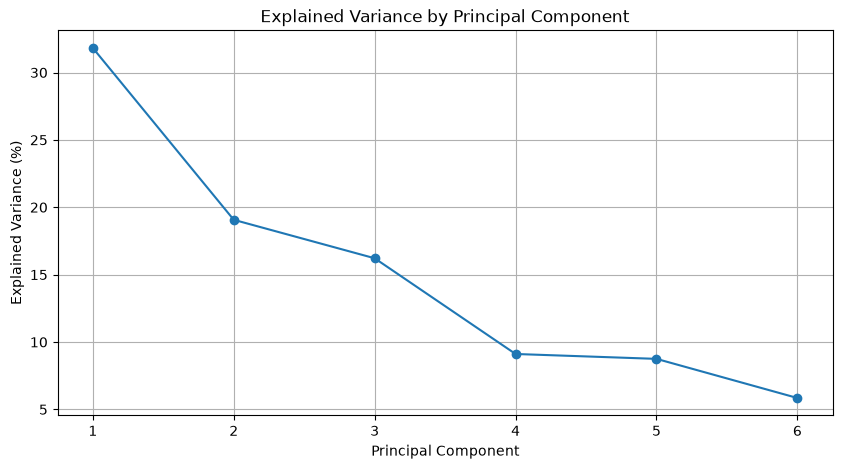

In [218]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    range(1, 7),
    pca_6.explained_variance_ratio_ * 100,
    marker="o"
)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance (%)")
plt.title("Explained Variance by Principal Component")
plt.xticks(range(1, 7))
plt.grid(True)

plt.show()

In [219]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

k_values = range(2, 9)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(pca_df)
    inertia.append(kmeans.inertia_)

print("Elbow method completed!")
print("Inertia values:", inertia)

Elbow method completed!
Inertia values: [4013417.336093063, 3122375.324572202, 2509442.48996493, 2168394.0760725522, 1987318.4036593006, 1819544.7795198571, 1649416.226345877]


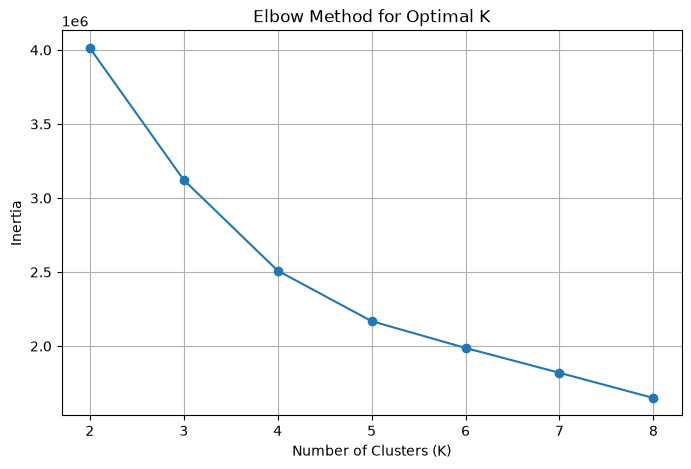

In [220]:
plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.xticks(k_values)
plt.grid(True)

plt.show()

In [221]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(pca_df)

print("K-Means clustering completed!")
print("Number of clusters:", len(set(cluster_labels)))

K-Means clustering completed!
Number of clusters: 3


In [222]:
pca_clustered = pca_df.copy()

pca_clustered["Cluster"] = cluster_labels

print(pca_clustered.head())

        PC1       PC2       PC3       PC4       PC5       PC6  Cluster
0 -0.117477  1.954626  1.591621  0.631568 -0.658989  0.106569        2
1 -0.332137 -1.867583  1.625901 -0.552006 -0.651548 -0.815901        0
2 -0.709170 -0.086317 -1.493901  0.064060 -0.658014 -0.075947        2
3 -1.066169  1.168017  0.566803  0.794564  2.382547  0.876877        2
4  2.656379  0.713088 -0.680967 -0.780568 -0.538823  1.801485        2


In [223]:
print("\nCluster distribution:")
print(
    pca_clustered["Cluster"]
    .value_counts()
    .sort_index()
)


Cluster distribution:
Cluster
0    119412
1      9373
2    371215
Name: count, dtype: int64


In [224]:
from sklearn.metrics import silhouette_score

silhouette_sample = pca_clustered.sample(
    n=10000,
    random_state=42
)

sil_score = silhouette_score(
    silhouette_sample[
        ["PC1", "PC2", "PC3", "PC4", "PC5", "PC6"]
    ],
    silhouette_sample["Cluster"]
)

print("Silhouette Score:", sil_score)

Silhouette Score: 0.3304707034714445


In [225]:
cluster_profile = pca_clustered.groupby("Cluster").mean(numeric_only=True)

print(cluster_profile.T)

Cluster         0         1         2
PC1     -0.300463  9.734259 -0.149133
PC2     -2.040192 -0.146701  0.659991
PC3      1.384254  0.104375 -0.447921
PC4     -0.038501 -0.000400  0.012395
PC5     -0.005277  0.508236 -0.011135
PC6      0.004010  0.006157 -0.001445


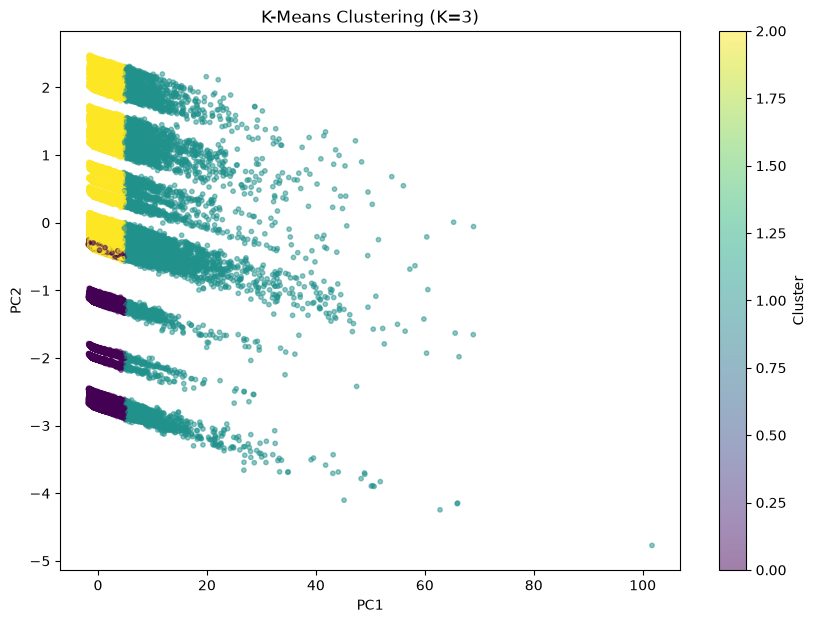

In [226]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

plt.scatter(
    pca_clustered["PC1"],
    pca_clustered["PC2"],
    c=pca_clustered["Cluster"],
    cmap="viridis",
    s=10,
    alpha=0.5
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clustering (K=3)")
plt.colorbar(label="Cluster")

plt.show()

In [227]:
cluster_counts = pca_clustered["Cluster"].value_counts().sort_index()

print("Cluster Counts:")
print(cluster_counts)

print("\nCluster Percentages:")
print((cluster_counts / len(pca_clustered) * 100).round(2))

Cluster Counts:
Cluster
0    119412
1      9373
2    371215
Name: count, dtype: int64

Cluster Percentages:
Cluster
0    23.88
1     1.87
2    74.24
Name: count, dtype: float64


In [120]:
for name in dir():
    if 'pca' in name.lower():
        print(name)

PCA
pca
pca_6
pca_6_result
pca_clustered
pca_columns
pca_data
pca_df
pca_features
pca_result
pca_sample
pca_scaled
scaler_pca


In [228]:
from sklearn.cluster import AgglomerativeClustering

hierarchical = AgglomerativeClustering(
    n_clusters=3,
    linkage='ward'
)

hierarchical_labels = hierarchical.fit_predict(X_pca_sample)

print("Hierarchical Clustering Completed!")

Hierarchical Clustering Completed!


In [229]:
from sklearn.metrics import silhouette_score

silhouette_hierarchical = silhouette_score(
    X_pca_sample,
    hierarchical_labels
)

print("Hierarchical Silhouette Score:",
      silhouette_hierarchical)

Hierarchical Silhouette Score: 0.31305548062217015


In [230]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import numpy as np

dbscan = DBSCAN(
    eps=0.5,
    min_samples=10
)

dbscan_labels = dbscan.fit_predict(X_pca_sample)

print("DBSCAN Clustering Completed!")

# Number of clusters (-1 = noise)
unique_labels = set(dbscan_labels)

print("Clusters:", unique_labels)
print("Number of clusters:",
      len(unique_labels - {-1}))

print("Noise points:",
      np.sum(dbscan_labels == -1))

DBSCAN Clustering Completed!
Clusters: {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(-1)}
Number of clusters: 32
Noise points: 1546


In [231]:
mask = dbscan_labels != -1

if len(set(dbscan_labels[mask])) > 1:
    dbscan_silhouette = silhouette_score(
        X_pca_sample[mask],
        dbscan_labels[mask]
    )

    print("DBSCAN Silhouette Score:",
          dbscan_silhouette)
else:
    print("Not enough clusters for Silhouette Score")

DBSCAN Silhouette Score: 0.15316811338649988


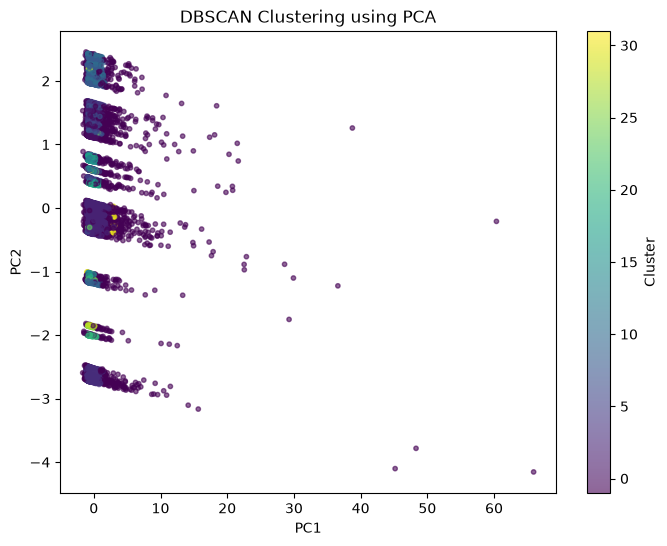

In [232]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca_sample[:, 0],
    X_pca_sample[:, 1],
    c=dbscan_labels,
    s=10,
    alpha=0.6
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("DBSCAN Clustering using PCA")
plt.colorbar(label="Cluster")

plt.show()

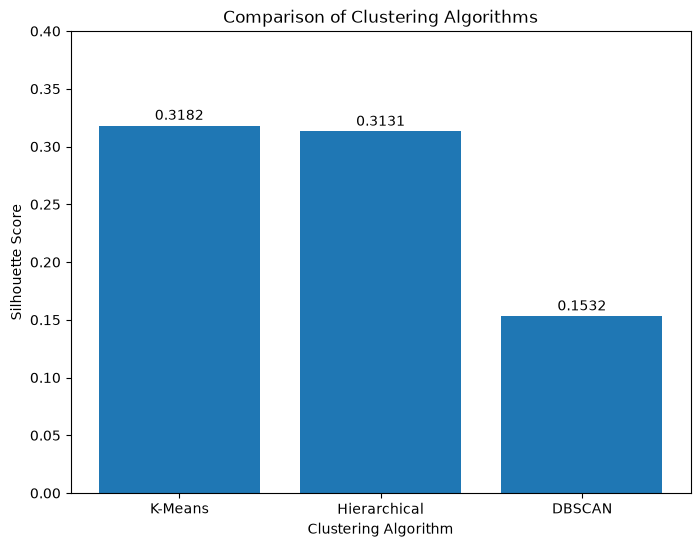

In [233]:
import matplotlib.pyplot as plt

# Silhouette scores
kmeans_score = 0.3182
hierarchical_score = 0.31305548062217015
dbscan_score = 0.15316811338649988

methods = [
    "K-Means",
    "Hierarchical",
    "DBSCAN"
]

scores = [
    kmeans_score,
    hierarchical_score,
    dbscan_score
]

plt.figure(figsize=(8, 6))

bars = plt.bar(methods, scores)

plt.xlabel("Clustering Algorithm")
plt.ylabel("Silhouette Score")
plt.title("Comparison of Clustering Algorithms")

# Display values on bars
for bar, score in zip(bars, scores):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f"{score:.4f}",
        ha="center"
    )

plt.ylim(0, 0.4)
plt.show()